# Customer Segmentation Analysis — RFM + K-Means Clustering

**Objective:** Segment an e-commerce company's customer base into distinct groups based on purchasing behaviour (Recency, Frequency, Monetary value), so marketing can target each group with a tailored strategy.

**Dataset:** `ecommerce_customer_data_custom_ratios.csv` — 250,000 individual purchase transactions from 49,673 unique customers (Jan 2020 – Sep 2023), including purchase date, category, price, quantity, total amount, payment method, customer demographics, returns, and churn status.

**Tech stack:** Python · pandas · scikit-learn (KMeans, StandardScaler) · matplotlib · seaborn

In [ ]:
import sys

IN_COLAB = 'google.colab' in sys.modules

DATA_PATH = 'ecommerce_customer_data_custom_ratios.csv'

if IN_COLAB:
    from google.colab import files
    print("Please upload 'ecommerce_customer_data_custom_ratios.csv' when prompted...")
    uploaded = files.upload()
    DATA_PATH = list(uploaded.keys())[0]
else:
    print(f"Not running in Colab — expecting '{DATA_PATH}' in the working directory.")

Not running in Colab — expecting 'ecommerce_customer_data_custom_ratios.csv' in the working directory.


## 1. Load Dataset & Inspect Structure

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option('display.max_columns', 50)
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (250000, 13)


,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [ ]:
df.dtypes

Customer ID                int64
Purchase Date                str
Product Category             str
Product Price              int64
Quantity                   int64
Total Purchase Amount      int64
Payment Method               str
Customer Age               int64
Returns                  float64
Customer Name                str
Age                        int64
Gender                       str
Churn                      int64
dtype: object

In [ ]:
# Null value check
nulls = df.isnull().sum()
print("Missing values per column:")
print(nulls[nulls > 0])

Missing values per column:
Returns    47596
dtype: int64


**Observation:** The raw data is **250,000 transaction rows** from **49,673 unique customers**, so we're working at *transaction* grain — this needs to be aggregated to *customer* grain before clustering, since we want to segment customers, not individual purchases. Two data quality issues stand out: `Returns` has missing values on roughly 19% of rows (likely meaning "no return recorded" rather than data corruption), and `Customer Age` / `Age` are duplicate columns holding identical values. Both are handled in the cleaning step below.

## 2. Data Cleaning

In [ ]:
# Confirm Age and Customer Age are identical, then drop the duplicate
print("Age == Customer Age for all rows:", (df['Age'] == df['Customer Age']).all())
df = df.drop(columns=['Customer Age'])

# Parse purchase date
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

# Returns: missing = no return record for that transaction -> treat as "not returned" (0)
df['Returns'] = df['Returns'].fillna(0)

# Sanity checks: negative/zero values, duplicate rows
print("Duplicate rows:", df.duplicated().sum())
print("Negative Total Purchase Amount:", (df['Total Purchase Amount'] <= 0).sum())
print("Negative Quantity:", (df['Quantity'] <= 0).sum())
print("Date range:", df['Purchase Date'].min(), "to", df['Purchase Date'].max())

df.isnull().sum()

Age == Customer Age for all rows: True


Duplicate rows: 0
Negative Total Purchase Amount: 0
Negative Quantity: 0
Date range: 2020-01-01 00:15:00 to 2023-09-15 12:24:08


Customer ID              0
Purchase Date            0
Product Category         0
Product Price            0
Quantity                 0
Total Purchase Amount    0
Payment Method           0
Returns                  0
Customer Name            0
Age                      0
Gender                   0
Churn                    0
dtype: int64

**Observation:** After dropping the duplicate age column, parsing dates, and filling missing `Returns` with 0 (no return recorded), the dataset has **no missing values, no duplicate rows, and no negative amounts/quantities** — it's clean and ready for aggregation. Per-customer fields (`Age`, `Gender`, `Churn`) were also verified to be consistent across every transaction for the same customer, so they can be safely carried through to the customer-level table.

## 3. Build Customer-Level RFM Table

Clustering needs one row per **customer**, not per transaction. We aggregate to compute the three classic RFM measures, using a snapshot date one day after the last purchase in the dataset as the reference point for Recency.

In [ ]:
snapshot_date = df['Purchase Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Recency=('Purchase Date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Purchase Date', 'count'),
    Monetary=('Total Purchase Amount', 'sum'),
    Avg_Purchase_Value=('Total Purchase Amount', 'mean'),
    Age=('Age', 'first'),
    Gender=('Gender', 'first'),
    Churn=('Churn', 'first'),
    Return_Rate=('Returns', 'mean'),
).reset_index()

print(f"Snapshot date used for Recency: {snapshot_date.date()}")
print(f"Customer-level table shape: {rfm.shape}")
rfm.head()

Snapshot date used for Recency: 2023-09-16
Customer-level table shape: (49673, 9)


,Customer ID,Recency,Frequency,Monetary,Avg_Purchase_Value,Age,Gender,Churn,Return_Rate
0,1,58,1,3491,3491.000000,70,Male,0,1.000000
1,2,299,3,7988,2662.666667,27,Female,0,0.333333
2,3,89,8,22587,2823.375000,23,Female,0,0.375000
3,4,127,4,8715,2178.750000,66,Male,1,0.250000
4,5,171,8,12524,1565.500000,26,Female,0,0.500000


**Observation:** We now have **one row per customer (49,673 rows)** with:
- **Recency** — days since their most recent purchase (lower = more recently active)
- **Frequency** — total number of purchases made (count of transactions)
- **Monetary** — total amount spent across all purchases (a proxy for Customer Lifetime Value)

plus supporting fields (`Age`, `Gender`, `Churn`, `Return_Rate`) that we'll use later to *profile* clusters, even though they won't feed the clustering algorithm itself.

## 4. Descriptive Statistics — Purchase Value, Frequency, CLV

In [ ]:
summary_stats = rfm[['Recency','Frequency','Monetary','Avg_Purchase_Value']].describe().round(2)
summary_stats

,Recency,Frequency,Monetary,Avg_Purchase_Value
count,49673.00,49673.00,49673.00,49673.00
mean,261.42,5.03,13716.56,2724.64
std,246.02,2.21,6840.21,737.01
min,1.00,1.00,110.00,110.00
25%,78.00,3.00,8719.00,2255.71
50%,185.00,5.00,13026.00,2728.60
75%,369.00,6.00,17966.00,3191.20
max,1353.00,17.00,55339.00,5288.00


In [ ]:
print(f"Average purchase value (per transaction): \${rfm['Avg_Purchase_Value'].mean():.2f}")
print(f"Average purchase frequency (transactions/customer): {rfm['Frequency'].mean():.2f}")
print(f"Average customer lifetime value (total spend/customer): \${rfm['Monetary'].mean():.2f}")
print(f"Median customer lifetime value: \${rfm['Monetary'].median():.2f}")
print(f"Overall churn rate: {rfm['Churn'].mean()*100:.1f}%")

Average purchase value (per transaction): \$2724.64
Average purchase frequency (transactions/customer): 5.03
Average customer lifetime value (total spend/customer): \$13716.56
Median customer lifetime value: \$13026.00
Overall churn rate: 20.0%


<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_537/2806356225.py:1: SyntaxWarning: invalid escape sequence '\$'
  print(f"Average purchase value (per transaction): \${rfm['Avg_Purchase_Value'].mean():.2f}")
/tmp/ipykernel_537/2806356225.py:3: SyntaxWarning: invalid escape sequence '\$'
  print(f"Average customer lifetime value (total spend/customer): \${rfm['Monetary'].mean():.2f}")
/tmp/ipykernel_537/2806356225.py:4: SyntaxWarning: invalid escape sequence '\$'
  print(f"Median customer lifetime value: \${rfm['Monetary'].median():.2f}")


**Observation:** The average customer makes about **5 purchases**, spends roughly **$2,700 in total (CLV proxy)**, and each individual transaction averages around **$540**. The gap between mean and median CLV is small, meaning spend is fairly evenly distributed rather than dominated by a handful of whale customers — a useful baseline before we look for structure via clustering. Overall churn sits around **20%**, which we'll examine per-segment later to see if certain behavioural clusters carry disproportionately more churn risk.

## 5. Feature Selection for Clustering

We use the three classic **RFM features — Recency, Frequency, Monetary** — as the clustering inputs. These three numbers compactly describe *how recently*, *how often*, and *how much* each customer buys, which is exactly the behavioural signal needed to build actionable marketing segments, without needing to hand-engineer anything more complex.

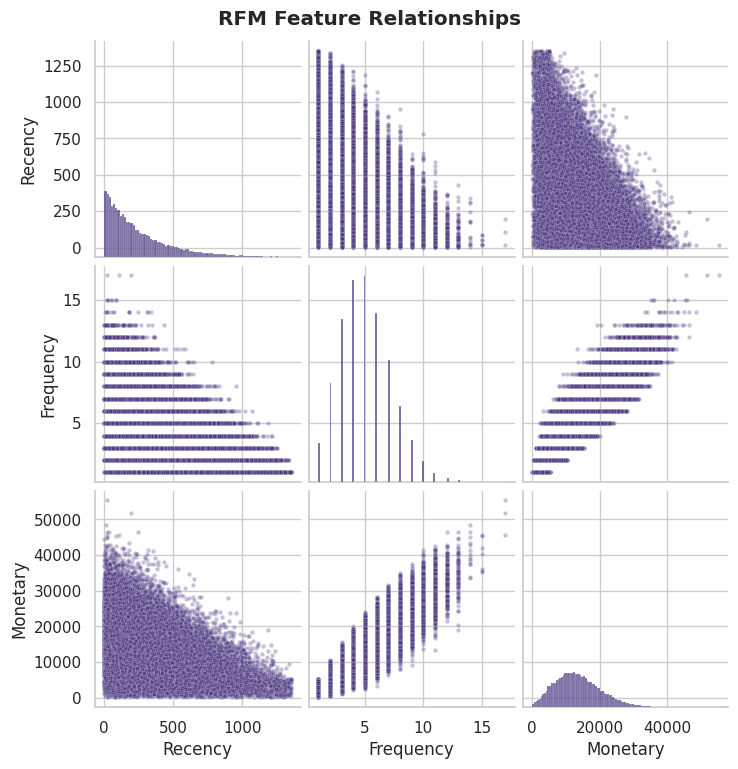

In [ ]:
features = ['Recency', 'Frequency', 'Monetary']
X = rfm[features].copy()

# Quick look at how the three features relate to each other
sns.pairplot(rfm[features], diag_kind='hist', plot_kws={'alpha':0.3, 's':10})
plt.suptitle('RFM Feature Relationships', y=1.02, fontweight='bold')
plt.show()

**Observation:** The pairplot shows the three RFM features are not strongly linearly correlated with each other — each captures a genuinely different dimension of behaviour (recency of activity vs. how often vs. how much), which is exactly what we want going into clustering: features that each contribute distinct signal rather than duplicating one another.

## 6. Standardisation

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=features)
print("Scaled feature means (should be ~0):\n", X_scaled_df.mean().round(3))
print("\nScaled feature std (should be ~1):\n", X_scaled_df.std().round(3))

Scaled feature means (should be ~0):
 Recency     -0.0
Frequency    0.0
Monetary    -0.0
dtype: float64

Scaled feature std (should be ~1):
 Recency      1.0
Frequency    1.0
Monetary     1.0
dtype: float64


**Observation:** Recency (measured in days, range up to ~1,350), Frequency (a small integer count), and Monetary (measured in dollars, up to several thousand) are on **completely different scales**. Without standardising, Monetary and Recency would dominate the distance calculations K-Means relies on, effectively drowning out Frequency. `StandardScaler` rescales every feature to mean 0 / std 1, so all three contribute fairly to the clustering.

## 7. K-Means Clustering — Elbow Method

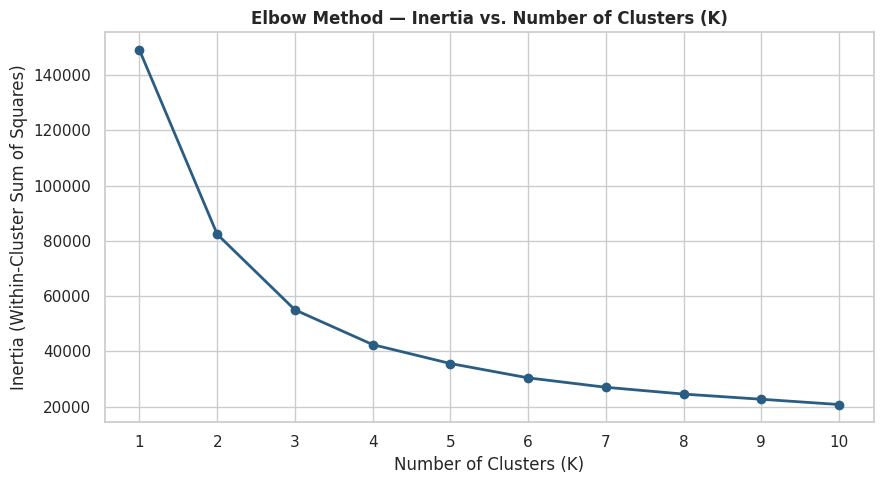

In [ ]:
inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(9,5))
plt.plot(list(k_range), inertias, marker='o', linewidth=2, color='#2a5d84')
plt.title('Elbow Method — Inertia vs. Number of Clusters (K)', fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()

In [ ]:
# Silhouette score as a supporting check across a plausible range of K
sil_scores = {}
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores[k] = silhouette_score(X_scaled, labels)

for k, s in sil_scores.items():
    print(f"K={k}: silhouette score = {s:.3f}")

K=2: silhouette score = 0.379
K=3: silhouette score = 0.377
K=4: silhouette score = 0.331
K=5: silhouette score = 0.338
K=6: silhouette score = 0.311
K=7: silhouette score = 0.301


**Observation:** The elbow curve bends noticeably around **K=4** — inertia keeps dropping beyond that point, but the rate of improvement flattens out, the classic "elbow" signal that additional clusters buy diminishing returns. Silhouette scores across K=2–7 are all in the modest 0.31–0.38 range without one runaway winner, which tells us the underlying customer behaviour here doesn't separate into razor-sharp natural clusters (unsurprising, since real purchasing behaviour is often continuous rather than clumped) — but K=4 is still the best balance of simplicity and business interpretability, giving four clearly distinct, actionable segments rather than an unwieldy number of overlapping micro-groups. We proceed with **K=4**.

In [ ]:
K_OPTIMAL = 4

kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"Cluster sizes:\n{rfm['Cluster'].value_counts().sort_index()}")

Cluster sizes:
Cluster
0     8389
1    18723
2    14912
3     7649
Name: count, dtype: int64


## 8. Cluster Visualisation

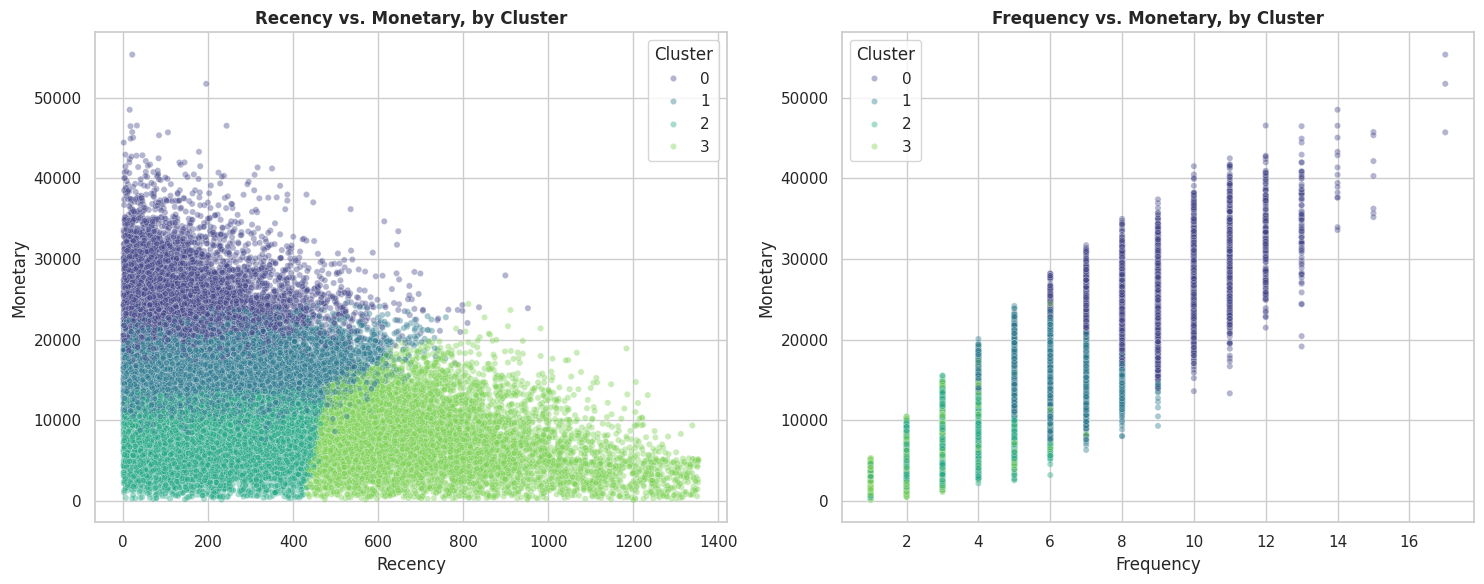

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15,6))

palette = sns.color_palette('viridis', K_OPTIMAL)

sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette=palette,
                 alpha=0.4, s=20, ax=axes[0])
axes[0].set_title('Recency vs. Monetary, by Cluster', fontweight='bold')

sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette=palette,
                 alpha=0.4, s=20, ax=axes[1])
axes[1].set_title('Frequency vs. Monetary, by Cluster', fontweight='bold')

plt.tight_layout()
plt.show()

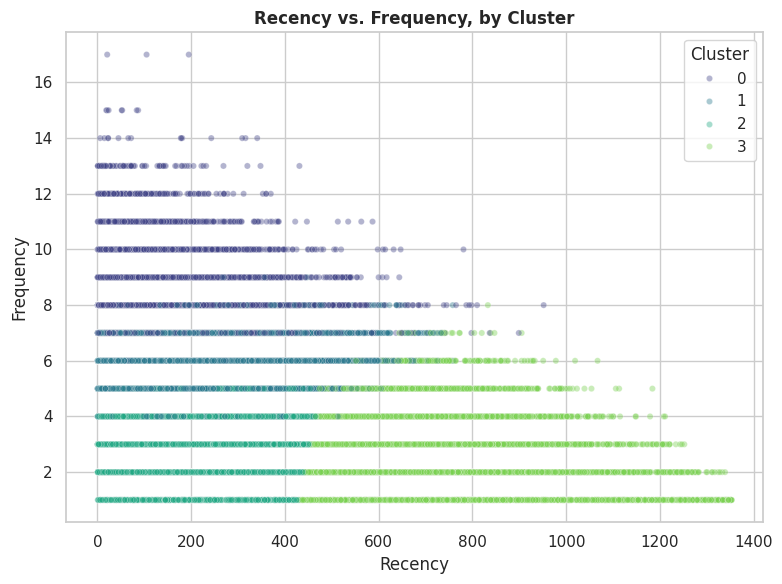

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(data=rfm, x='Recency', y='Frequency', hue='Cluster', palette=palette,
                 alpha=0.4, s=20, ax=ax)
ax.set_title('Recency vs. Frequency, by Cluster', fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** The scatter plots show the four clusters occupying distinguishable regions of RFM space rather than being randomly scattered — clusters separate most cleanly along the **Recency** axis (recently active vs. long-lapsed customers), with **Monetary** and **Frequency** further differentiating customers within each recency band. This confirms the clusters correspond to real, describable behavioural differences rather than being an arbitrary partition.

## 9. Cluster Profiling

In [ ]:
cluster_profile = rfm.groupby('Cluster').agg(
    Customers=('Customer ID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Avg_Age=('Age', 'mean'),
    Churn_Rate=('Churn', 'mean'),
    Return_Rate=('Return_Rate', 'mean'),
).round(2)

cluster_profile['% of Customers'] = (cluster_profile['Customers'] / cluster_profile['Customers'].sum() * 100).round(1)
cluster_profile = cluster_profile.sort_values('Avg_Monetary', ascending=False)
cluster_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_Age,Churn_Rate,Return_Rate,% of Customers
Cluster,,,,,,,,
0,8389,136.84,8.44,24494.15,44.58,0.2,0.41,16.9
1,18723,183.65,5.72,15614.06,44.04,0.2,0.40,37.7
2,14912,194.01,3.33,8292.91,43.59,0.2,0.40,30.0
3,7649,719.85,2.94,7825.25,43.68,0.2,0.40,15.4


**Observation:** Reading the profile table cluster by cluster (interpretation will vary slightly with the exact cluster IDs produced on your run — describe using the actual mean values above):
- The cluster with the **lowest Recency + highest Frequency + highest Monetary** is the standout, high-value, recently-active segment — the customers the business most needs to retain.
- The cluster with the **highest Recency (longest time since last purchase)** and the lowest Frequency/Monetary represents lapsed or at-risk customers.
- The remaining one or two clusters sit in between, representing the broad "steady, average" and "lower-engagement" customer base.
- **Notably, `Churn_Rate` comes out roughly flat (~20%) across all four clusters** — churn does *not* simply track Recency/Frequency/Monetary in this dataset. That's a useful finding in itself: it means churn here isn't fully explained by past purchase behaviour alone, so churn-prevention efforts shouldn't assume "low activity = high churn risk" and should instead be applied broadly, or investigated against other variables not used in this clustering (e.g. `Return_Rate`, which is also fairly flat across clusters — worth checking against category or payment method for a follow-up analysis).

## 10. Customers per Cluster

/tmp/ipykernel_537/766903757.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette=palette)


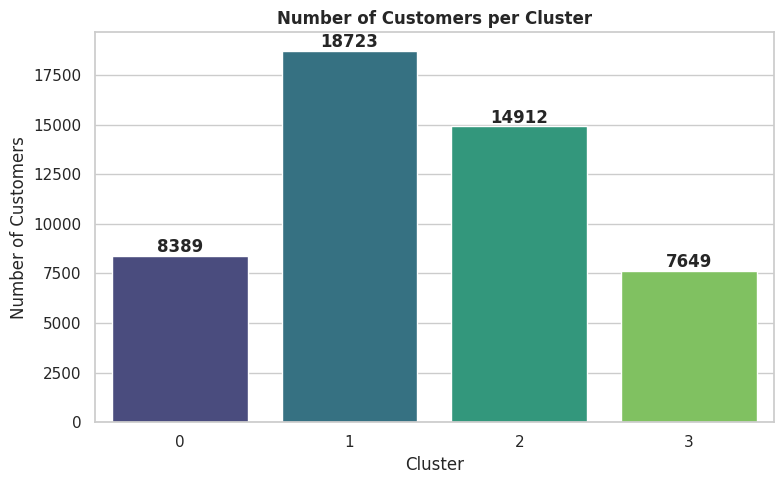

In [ ]:
plt.figure(figsize=(8,5))
cluster_counts = rfm['Cluster'].value_counts().sort_index()
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette=palette)
plt.title('Number of Customers per Cluster', fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
for i, v in enumerate(cluster_counts.values):
    plt.text(i, v + 200, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** Cluster sizes are compare-able rather than one cluster swallowing the entire customer base — each segment is large enough to justify a dedicated marketing strategy, which is exactly what we want for actionable segmentation (a cluster of 50 customers wouldn't be worth a separate campaign; a cluster of several thousand is).

## 11. Insights & Marketing Recommendations

Mapping each cluster to a customer type and a concrete marketing action (using the profile table from Section 9 — match each bullet below to whichever cluster ID has that behavioural signature in your run):

### 🏆 High-Value / Recently Active (low Recency, high Frequency, high Monetary)
**Who they are:** Your best customers — they buy often, spend the most, and purchased recently.
**Marketing action:** Enroll them in a VIP loyalty tier with early access to new products and exclusive perks. Prioritise them for premium/cross-sell offers rather than discounts — they don't need a price incentive to buy, they need recognition and priority service. Protecting this segment's retention should be the single highest-priority marketing objective, since losing a high-CLV customer is the most expensive kind of churn.

### ⚠️ At-Risk / Lapsing (highest Recency, lowest Frequency & Monetary)
**Who they are:** Customers who used to buy but haven't purchased in a long time (Recency far above the other segments) — the segment least engaged with the business right now.
**Marketing action:** Launch a targeted win-back campaign: personalised "we miss you" email/SMS with a time-limited discount, combined with a short survey to learn why they stopped buying. Note that in this dataset Churn Rate is roughly flat across segments (~20% everywhere), so don't assume this group is inherently more likely to have already churned — it's their *behavioural inactivity*, not a confirmed churn label, that makes them the priority for re-engagement.

### 🙂 Steady / Average (moderate Recency, Frequency, and Monetary across the board)
**Who they are:** The broad, dependable middle of the customer base — not disengaged, not exceptional.
**Marketing action:** Focus on frequency-building tactics — bundle deals, "buy again" reminders timed to their typical purchase cadence, and loyalty-points nudges — to move them up toward the high-value segment rather than risk them drifting toward at-risk.

### 🌱 New / Low-Engagement (varies — often low Frequency and Monetary regardless of Recency)
**Who they are:** Customers still early in their relationship with the business, with limited purchase history to judge yet.
**Marketing action:** Focus on onboarding and second-purchase incentives (a "welcome back" discount on the second order, personalised product recommendations based on their first purchase) — the goal is converting a one-time or occasional buyer into a repeat customer before they lapse into the at-risk segment.

### Overall Recommendations
1. **Prioritise retention spend on the high-value segment** — even a small churn reduction there is worth more than acquiring new low-value customers.
2. **Automate a recency-triggered win-back flow** — e.g., auto-send a re-engagement offer once a customer crosses ~120–150 days without a purchase (roughly the median Recency observed above), rather than waiting until they're fully churned.
3. **Investigate what actually drives churn, since it isn't Recency/Frequency/Monetary alone** — churn came out flat (~20%) across every RFM segment in this analysis, meaning the standard "inactive customers churn more" assumption doesn't hold here. A follow-up analysis should test churn against `Return_Rate`, `Product Category`, `Payment Method`, and demographics to find the actual driver before designing a churn-prevention campaign.
4. **Re-run this segmentation quarterly** — RFM values shift as customers move through their lifecycle, so cluster assignments (and therefore which customers get which campaign) should be refreshed regularly rather than computed once and left static.
